In [1]:
import os
import requests
import sys
import json
from min_dalle_stub.text_tokenizer import TextTokenizer
import numpy, torch
from min_dalle_stub.dalle_bart_encoder import DalleBartEncoder
from min_dalle_stub.dalle_bart_decoder import DalleBartDecoder
from copy import deepcopy
from min_dalle_stub.vqgan_detokenizer import VQGanDetokenizer
from PIL import Image
from transformers import AutoTokenizer
from emoji import demojize

/root/miniconda3/envs/new_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
'''定义要用到的各种路径 + 下载文件'''


# 定义 Hugging Face 上 min-dalle 模型的下载基础 URL
url='https://hf-mirror.com/kuprel/min-dalle/resolve/main/'


# 定义用于存储模型文件和配置文件的目录路径
folder="files"

# 检查目录是否存在，如果不存在则创建
if not os.path.exists(folder):
    os.makedirs(folder)

# 采用BPE(Byte Pair Encoding, 字节对编码)算法【PPT讲解】

# 定义词表文件路径
vocab_path = folder + "/vocab.json"

# 定义合并规则文件路径（该文件用于决定如何拼接子词）
merges_path = folder + "/merges.txt"

# 检查词汇表和合并规则文件是否都已存在
if os.path.exists(vocab_path) == False or os.path.exists(merges_path) == False:
    print("下载文件")
    
    # 下载 vocab.json 文件
    vocab = requests.get(url + 'vocab.json')

    # 下载 merges.txt 文件
    merges = requests.get(url + 'merges.txt')
    
    # 将下载的 vocab 内容写入本地文件
    with open(vocab_path, 'wb') as f: 
        f.write(vocab.content)
    
    # 将下载的 merges 内容写入本地文件
    with open(merges_path, 'wb') as f:
        f.write(merges.content)   
else:
    print("vocab和merges文件都已存在")

vocab和merges文件都已存在


In [3]:
'''创建分词器'''


print("初始化分词器")

# 加载词表
with open(vocab_path, 'r', encoding='utf8') as f:
    vocab = json.load(f)

# 加载合并规则文件，并按行分割，去掉首尾行
with open(merges_path, 'r', encoding='utf8') as f:
    merges = f.read().split("\n")[1:-1]

# 初始化文本分词器，用于将文本转换为 token ID 序列
tokenizer = TextTokenizer(vocab, merges)

初始化分词器


In [4]:
'''进行文本分词'''


# 定义输入的文本prompt
text = "panda with top hat reading a book"

# 使用分词器将文本转换为 token ID 列表
token_ids = tokenizer.tokenize(text)

print("Token的数字索引:", token_ids)


# 创建一个新的字典，该字典的key是token id，value是token字符串
idx2token = {v: k for k, v in vocab.items()}

# 遍历token_ids中的各索引，将数字索引转换回对应的token字符串，未知 token 用 <unk> 表示
raw_tokens = [idx2token[i] for i in token_ids]

print("原始Tokens:", raw_tokens)

Token的数字索引: [0, 8418, 208, 479, 2583, 4132, 58, 407, 2]
原始Tokens: ['<s>', 'Ġpanda', 'Ġwith', 'Ġtop', 'Ġhat', 'Ġreading', 'Ġa', 'Ġbook', '</s>']


In [5]:
# 检查是否有可用的 GPU，如果有则使用 cuda，否则使用 cpu
device="cuda" if torch.cuda.is_available() else "cpu"

In [6]:
'''构建输入张量'''


# 初始化一个形状为 (2, 64) 的 numpy 数组，用 1 填充（1对应<pad> token）
text_tokens = numpy.ones((2, 64), dtype=numpy.int32)
# text_tokens的第一行用于无条件生成（存放空白提示词），第二行用于有条件生成（存放实际提示词）

# 将text_tokens中第0行的前2个元素，分别替换为<s>和</s>的索引（告诉模型，这里没有具体的文本内容，就只有一句话的开始和结束，剩余都是<pad>）
text_tokens[0, :2] = [token_ids[0], token_ids[-1]]
# text_tokens的第0行变成：[0, 2, 1, 1, 1, 1, ..., 1, 1]

# 把实际的文本token索引填充到text_tokens的第1行（实际是第二行）
text_tokens[1, :len(token_ids)] = token_ids
# text_tokens的第0行变成：[真实token索引序列, 1, 1, ..., 1, 1]

# 将text_tokens转换成tensor格式
text_tokens = torch.tensor(text_tokens, dtype = torch.long, device = device)

print(text_tokens)

tensor([[   0,    2,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1],
        [   0, 8418,  208,  479, 2583, 4132,   58,  407,    2,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,    1,
            1,    1,    1,    1]], device='cuda:0')


In [7]:
'''进行文本编码'''


# 定义 BART 编码器模型文件的本地路径
encoder_path = folder+"/encoder.pt"
  
# 如果编码器模型文件不存在，则从Hugging Face下载
if not os.path.exists(encoder_path):
    print("下载预训练好的编码器权重文件")

    ws = requests.get(url + 'encoder.pt')

    with open(encoder_path, 'wb') as f: 
        f.write(ws.content)
else:
    print("编码器文件已存在")

# 定义使用的数据类型为 float16（能在几乎不损失画质的情况下，将显存占用砍半，并大幅提升计算速度）
dtype = "float32" 

print("开始初始化DalleBartEncoder")

# 初始化 BART 编码器
encoder = DalleBartEncoder( # DalleBartEncoder: min-DALLE 的文本编码器部分，基于 BART 架构
    attention_num_heads = 32, # attention_head_count: 注意力头的数量
    d_model = 2048, # embed_count: 嵌入向量的维度
    glu_embed_dim = 4096, # glu_embed_count: GLU 激活函数的嵌入维度
    text_token_count = 64, # text_token_count: 文本 token 的最大长度
    text_vocab_count = 50272, # text_vocab_count: 文本词汇表的大小
    layer_count = 24, # layer_count: 编码器层数
    device = device # device: 运行设备
).to(getattr(torch, dtype)).eval() # 转换为 float16 并设置为评估模式

# 加载预训练的编码器权重
params = torch.load(encoder_path, weights_only=False)

encoder.load_state_dict(params, strict=False)

# 删除 params 以释放内存
del params

# 确保编码器在正确的设备上
encoder = encoder.to(device)

# 进行前向传播，计算文本向量
encoder_state = encoder.forward(text_tokens) # 将形状为[2, 63]的token id输入给编码器模型，编码为包含语义信息的向量
# encoder_state的形状：[2, 64, 2048]（每个token编码为2048维的向量）

# 清理 GPU 缓存
torch.cuda.empty_cache()

print("文本向量的形状:", encoder_state.shape)

编码器文件已存在
开始初始化DalleBartEncoder
文本向量的形状: torch.Size([2, 64, 2048])


In [11]:
'''图像 Token 的自回归生成'''


# 定义 BART 解码器模型文件的路径
decoder_path = folder+"/decoder.pt"
  
# 如果解码器模型文件不存在，则下载
if not os.path.exists(decoder_path):
    print("下载解码器权重文件")

    weights = requests.get(url + 'decoder.pt')
    
    with open(decoder_path, 'wb') as f: 
        f.write(weights.content)
else:
    print("解码器文件已存在")


print("初始化解码器")

# 实例化 BART 解码器
decoder = DalleBartDecoder( # DalleBartDecoder: 负责根据文本嵌入生成图像 token 序列
    image_vocab_count = 16415, # image_vocab_count: VQGAN的图像离散Codebook的大小
    attention_head_count = 32,
    embed_count = 2048,
    glu_embed_count = 4096,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()

# 加载预训练的解码器权重
params = torch.load(decoder_path, weights_only=False)

decoder.load_state_dict(params, strict=False)

del params

decoder = decoder.to(device)


# attention_mask用于指示哪些token是实际的，哪些是<pad>（找出来不等于1的元素，标记为True，其余标记为False）
attention_mask = text_tokens.not_equal(1)[:, None, None, :]
# attention_mask的作用：让解码器在参考文本特征时，只关注实际的单词，忽略<pad>；形状：[2, 1, 1, 64]；
# 这里是创建了交叉注意力掩码，让解码器在参考文本特征时，只关注实际的单词，忽略后面那些用来凑数的 padding

# attention_state用于存储KV cache
attention_state = torch.zeros(size = (24, 4, 256, 2048), dtype = getattr(torch, dtype), device = device)
# attention_state的形状：[24, 4, 256, 2048]，含义：24：网络共有24层
#                                                  4：无条件和有条件2个批次 × (K, V)
#                                                256：最终图像要生成256个token
#                                               2048：特征向量的维度

# 初始化一个空白数组，用于表示“空白画布”
image_tokens = torch.full((1, 256 + 1), 2 ** 14 - 1, dtype = torch.long, device = device)
# image_tokens的形状：[1, 257]（因为minDALLE生成的图像分辨率是16*16，+1是因为序列开头需要一个起始符）
# image_tokens中的元素都是16383，表示<BOS>起始符

# token_indices用于告诉模型当前画到了第几个格子
token_indices = torch.arange(256, device = device) # token_indices: [0, 1, 2, ..., 255]


# 设置采样温度，控制生成的随机性
# 较低的温度使分布更尖锐，生成更确定的结果
temperature = 0.5

# 每次只看概率最高的前top_k个色块，不考虑其他选项
top_k = 128

# supercondition_factor用于设置无分类器引导的强度
supercondition_factor = 6 # 数值设置为4表示强烈要求模型按照提示词的内容来生成

# 将这三个参数打包为Tensor
settings = torch.tensor([temperature, top_k, supercondition_factor], dtype = torch.float32, device = device)

with torch.no_grad():
    # 循环生成 256 个图像 token
    for i in range(256):
        torch.cuda.empty_cache()

        # 调用decoder的sample_tokens，生成下一个图像token
        image_tokens[:, i + 1], attention_state = decoder.sample_tokens( # 将预测出的一个数字（0~16383）写入空白画布image_tokens的第i + 1个位置。
                                                                        # 更新attention_state，将新生成的特征加入缓存，留给下一步用。
                        settings = settings, # 前面设置的3个参数
                        attention_mask = attention_mask, # 指示哪些token是<pad>
                        encoder_state = encoder_state, # 文本向量
                        attention_state = attention_state, # 之前的状态缓存
                        prev_tokens = image_tokens[:, [i]], # 刚才生成的最新一个token（形状：[1, 1]）
                        token_index = token_indices[[i]] # 当前生成的token索引
                        )
        # 随着循环进行，image_tokens从[16383, 16383, 16383, ...]逐渐被填满，比如变成[16383, 1024, 8562, 12, ...]
        # 循环结束时，就得到了一个填满真实预测值的[1, 257]形状的张量。

解码器文件已存在
初始化解码器


In [12]:
'''
此时，模型已经像拼图一样，选出了256个代表特定图像特征的Token IDs。但这256个数字只是抽象的隐变量，人类是看不懂的。
接下来的工作，就是把这些数字“翻译”成由红绿蓝（RGB）像素点组成的真实物理图像。
'''

'\n此时，模型已经像拼图一样，选出了256个代表特定图像特征的Token IDs。但这256个数字只是抽象的隐变量，人类是看不懂的。\n接下来的工作，就是把这些数字“翻译”成由红绿蓝（RGB）像素点组成的真实物理图像。\n'

detokenizer parameters have already been downloaded
initializing VQGanDetokenizer


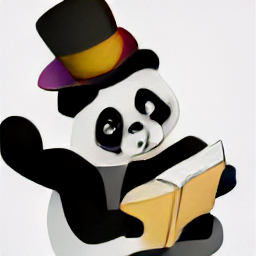

In [13]:
'''将token解码为像素图像并保存'''


# 定义VQGAN解码器（Detokenizer）模型文件的路径
detokenizer_path = folder + "/detoker.pt"

# 如果模型文件不存在，则下载
if not os.path.exists(detokenizer_path):
    print("downloading detokenizer parameters")

    ws = requests.get(url + 'detoker.pt')

    with open(detokenizer_path, 'wb') as f: 
        f.write(ws.content)
else:
    print("detokenizer parameters have already been downloaded")

print("initializing VQGanDetokenizer")


# 初始化VQGAN解码器（用于将图像token序列还原为像素图像）
detokenizer = VQGanDetokenizer().eval()

# 加载预训练权重
params = torch.load(detokenizer_path, weights_only=False)

detokenizer.load_state_dict(params)

# 删除权重
del params

# 放到GPU/CPU上
detokenizer = detokenizer.to(device)

# 清空缓存
torch.cuda.empty_cache()


# 使用VQGAN解码器将最终生成的图像token序列转换为图像
image = detokenizer.forward(True, image_tokens[:, 1:]) # image_tokens[:, 1:]：把第0个占位符去掉，只保留模型真正预测出的那256个代表画面的token  
# image是[256, 256, 3]的一个图像张量

# 将图像Tensor转换为uint8类型的numpy数组，并移动到CPU
image = image.to(torch.uint8).to('cpu').numpy()

# 将image转换为PIL Image对象的格式
image = Image.fromarray(image)

# 保存生成的图像
image.save("files/minDALLE.png")

# 显示图像
image